# LUCY -- Notebook 5: Demo Fight Detection
## Prueba del modelo FightLSTM entrenado en RLVS

Este notebook carga el modelo entrenado (`models/fight_detector.pth`) y lo prueba de tres formas:

1. **Predicciones en tabla** — muestra clase predicha y confianza sobre varios videos reales
2. **Esqueleto sobre frames reales** — dibuja los 17 keypoints COCO encima del video original
3. **Probabilidad a lo largo del tiempo** — muestra cómo el BiLSTM acumula confianza frame a frame


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os, glob, random
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
random.seed(42); np.random.seed(42); torch.manual_seed(42)

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
# ── Mismas constantes que el notebook de entrenamiento ───────────────────────
DATASET_DIR  = 'datasets/Real Life Violence Dataset'
SAVE_PATH    = 'models/fight_detector.pth'
N_FRAMES     = 30
N_PEOPLE     = 2
N_KP         = 17
FEATURES     = N_PEOPLE * N_KP * 2   # 68
HIDDEN_SIZE  = 256
NUM_LAYERS   = 2
DROPOUT      = 0.4
CLASSES      = ['NonViolence', 'Violence']
N_CLASSES    = 2

COLORS_CLASS = {'NonViolence': '#4CAF50', 'Violence': '#F44336'}

# ── Arquitectura FightLSTM (identica al entrenamiento) ────────────────────────
class FightLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(FEATURES, 128), nn.ReLU(), nn.Dropout(DROPOUT))
        self.lstm = nn.LSTM(
            input_size=128, hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS, batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0.0, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(HIDDEN_SIZE * 2, 128), nn.ReLU(), nn.Dropout(DROPOUT),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, N_CLASSES))

    def forward(self, x):
        B, T, _ = x.shape
        proj   = self.input_proj(x.view(B * T, -1)).view(B, T, 128)
        out, _ = self.lstm(proj)
        logits = self.classifier(out[:, -1, :])
        return {'logits': logits, 'probs': F.softmax(logits, dim=-1)}

print('Arquitectura definida OK')

Arquitectura definida OK


In [5]:
assert os.path.exists(SAVE_PATH), f'No se encontro {SAVE_PATH} — ejecuta primero el Notebook 4'

model = FightLSTM().to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True))
model.eval()

total_p = sum(p.numel() for p in model.parameters())
print(f'Modelo cargado desde: {SAVE_PATH}')
print(f'Parametros: {total_p:,}  |  Device: {DEVICE}')

Modelo cargado desde: models/fight_detector.pth
Parametros: 2,450,370  |  Device: cuda


In [6]:
_pose_model = None

def _get_pose_model():
    global _pose_model
    if _pose_model is None:
        _pose_model = YOLO('yolov8n-pose.pt')
    return _pose_model


def _normalize_keypoints(kp_pixels, img_w, img_h):
    kp = kp_pixels.astype(np.float32).copy()
    kp[:, 0] /= (img_w + 1e-6)
    kp[:, 1] /= (img_h + 1e-6)
    hip_center      = (kp[11] + kp[12]) / 2.0
    shoulder_center = (kp[5]  + kp[6])  / 2.0
    torso_height    = float(np.linalg.norm(shoulder_center - hip_center)) + 1e-6
    if torso_height < 0.02:
        visible = kp[(kp[:, 0] > 0.01) | (kp[:, 1] > 0.01)]
        if len(visible) >= 2:
            hip_center = visible.mean(axis=0); torso_height = 0.15
        else:
            return kp.flatten()
    return ((kp - hip_center) / torso_height).flatten()


def extract_keypoints(video_path):
    """Extrae (N_FRAMES, FEATURES) de un video. Igual que Notebook 4."""
    pose   = _get_pose_model()
    cap    = cv2.VideoCapture(video_path)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return np.zeros((N_FRAMES, FEATURES), dtype=np.float32)
    indices = np.linspace(0, total - 1, N_FRAMES, dtype=int)
    out     = np.zeros((N_FRAMES, FEATURES), dtype=np.float32)
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret or frame is None: continue
        h, w = frame.shape[:2]
        res  = pose(frame, verbose=False, device=DEVICE)
        if not res or res[0].keypoints is None or len(res[0].boxes) == 0: continue
        kp_data = res[0].keypoints.xy.cpu().numpy()
        conf    = res[0].boxes.conf.cpu().numpy()
        order   = np.argsort(conf)[::-1]
        for slot, pid in enumerate(order[:N_PEOPLE]):
            kn    = _normalize_keypoints(kp_data[pid], w, h)
            start = slot * N_KP * 2
            out[i, start:start + N_KP * 2] = kn
    cap.release()
    return out


def predict(video_path):
    """
    Predice FIGHT / NO_FIGHT en un video.
    Retorna dict con pred, confidence, probs, keypoints.
    """
    kp = extract_keypoints(video_path)
    x  = torch.tensor(kp, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(x)
    idx  = out['probs'].argmax(-1).item()
    return {
        'pred':       CLASSES[idx],
        'confidence': float(out['probs'][0, idx]),
        'probs':      {CLASSES[i]: float(out['probs'][0, i]) for i in range(N_CLASSES)},
        'keypoints':  kp,
    }


print('Funciones de inferencia listas')

Funciones de inferencia listas


## Test 1 — Predicciones en tabla

Tomamos 5 videos de cada clase al azar y mostramos:
- Clase real
- Clase predicha por el modelo
- Confianza (probabilidad de la clase elegida)
- Correcto o incorrecto


In [9]:
N_SAMPLES = 5   # videos por clase a probar

results = []
for cls_idx, cls_name in enumerate(CLASSES):
    folder = os.path.join(DATASET_DIR, cls_name)
    videos = sorted(glob.glob(os.path.join(folder, '*.mp4')))
    # Tomar los ultimos N_SAMPLES para asegurarse de que no esten en el train split
    sample = videos[-N_SAMPLES:]
    for vpath in sample:
        r    = predict(vpath)
        ok   = 'OK' if r['pred'] == cls_name else 'FALLO'
        results.append({
            'archivo':  os.path.basename(vpath),
            'real':     cls_name,
            'predicho': r['pred'],
            'confianza': f"{r['confidence']*100:.1f}%",
            'resultado': ok,
        })
        print(f"[{ok:5s}]  {os.path.basename(vpath):<18s}  "
              f"real={cls_name:12s}  pred={r['pred']:12s}  "
              f"conf={r['confidence']*100:.1f}%")

# Resumen
n_ok = sum(1 for r in results if r['resultado'] == 'OK')
print(f'\nAciertos: {n_ok}/{len(results)}  ({n_ok/len(results)*100:.0f}%)')

[OK   ]  NV_995.mp4          real=NonViolence   pred=NonViolence   conf=100.0%
[OK   ]  NV_996.mp4          real=NonViolence   pred=NonViolence   conf=100.0%
[OK   ]  NV_997.mp4          real=NonViolence   pred=NonViolence   conf=100.0%
[OK   ]  NV_998.mp4          real=NonViolence   pred=NonViolence   conf=100.0%
[OK   ]  NV_999.mp4          real=NonViolence   pred=NonViolence   conf=100.0%
[OK   ]  V_995.mp4           real=Violence      pred=Violence      conf=96.1%
[OK   ]  V_996.mp4           real=Violence      pred=Violence      conf=100.0%
[OK   ]  V_997.mp4           real=Violence      pred=Violence      conf=99.9%
[OK   ]  V_998.mp4           real=Violence      pred=Violence      conf=99.9%
[OK   ]  V_999.mp4           real=Violence      pred=Violence      conf=100.0%

Aciertos: 10/10  (100%)


## Test 2 — Esqueleto sobre frames reales

Mostramos 6 frames distribuidos a lo largo del video con el esqueleto COCO dibujado encima.
Esto visualiza exactamente qué información procesa el modelo — no píxeles, sino posiciones de cuerpo.

**Verde** = NonViolence  |  **Rojo** = Violence


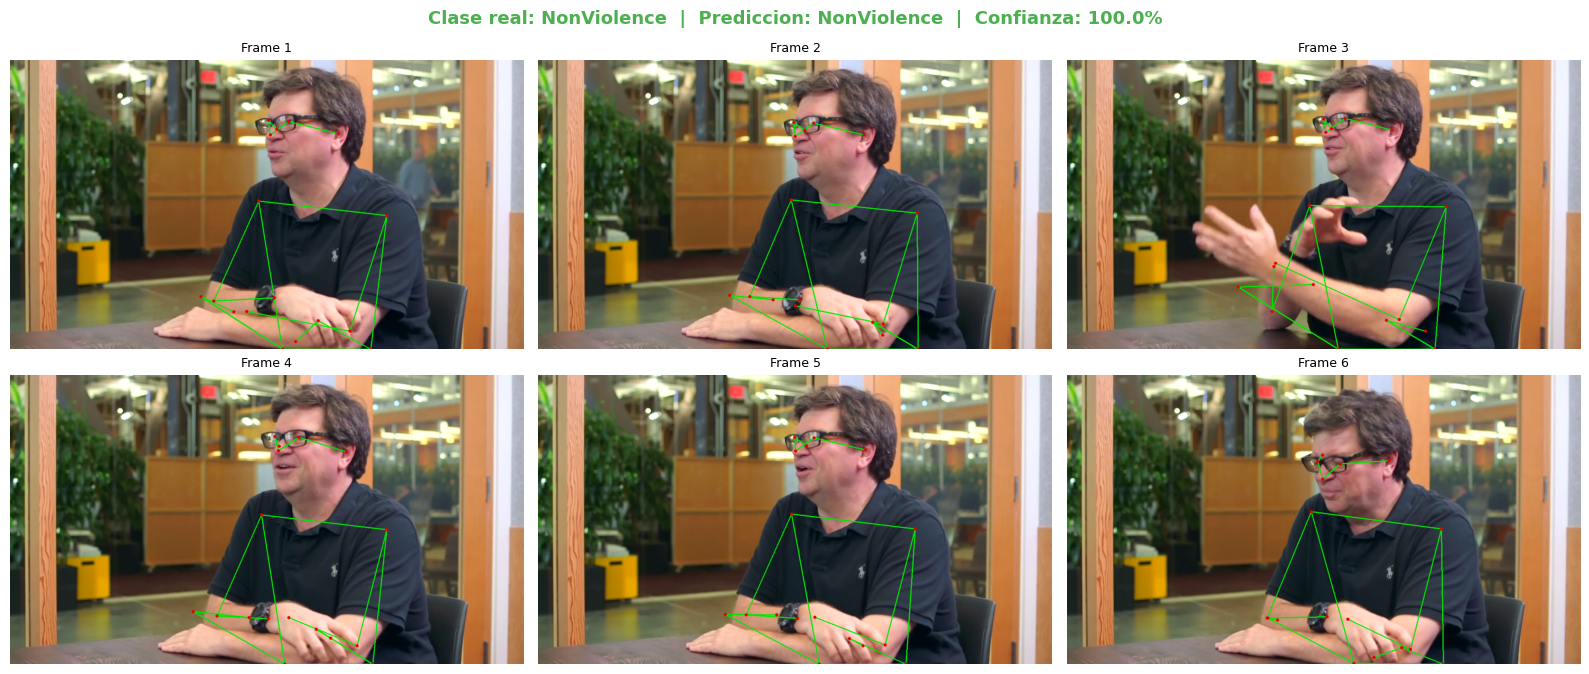

NonViolence: pred=NonViolence  conf=100.0%
  NonViolence prob: 100.0%  Violence prob: 0.0%


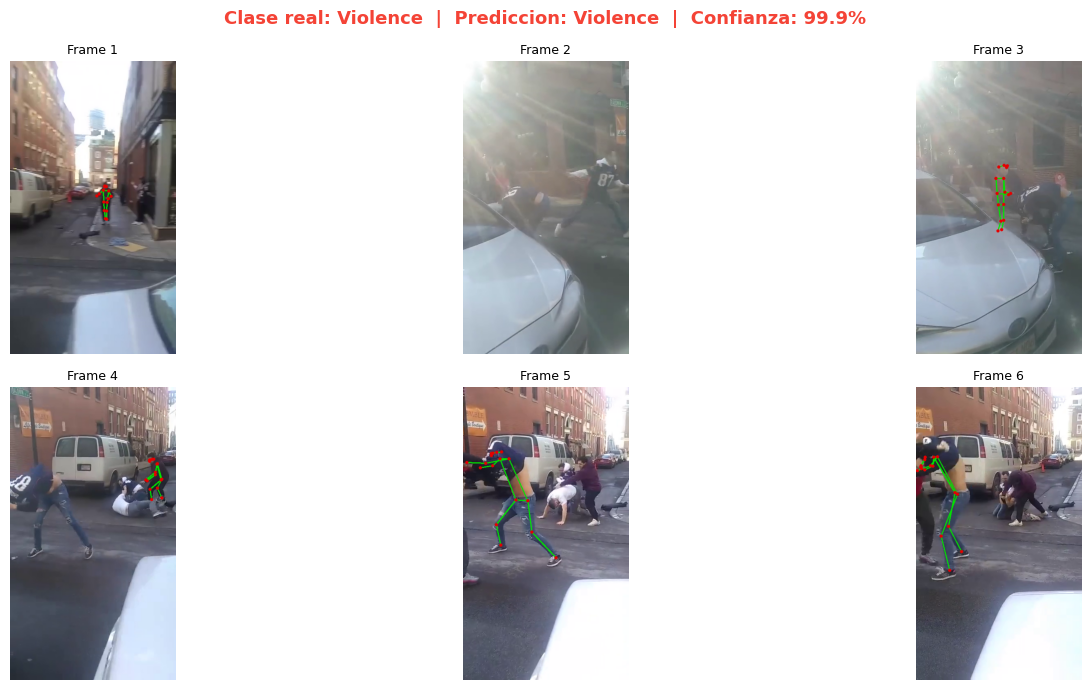

Violence: pred=Violence  conf=99.9%
  NonViolence prob: 0.1%  Violence prob: 99.9%


In [10]:
SKELETON_COCO = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16),
]

def draw_skeleton_on_frame(frame, kp_xy):
    """
    Dibuja el esqueleto COCO-17 sobre un frame BGR.
    kp_xy: np.ndarray (17, 2) en pixeles
    """
    out = frame.copy()
    for (a, b) in SKELETON_COCO:
        xa, ya = int(kp_xy[a, 0]), int(kp_xy[a, 1])
        xb, yb = int(kp_xy[b, 0]), int(kp_xy[b, 1])
        if xa > 0 and ya > 0 and xb > 0 and yb > 0:
            cv2.line(out, (xa, ya), (xb, yb), (0, 230, 0), 2)
    for kp in kp_xy:
        x, y = int(kp[0]), int(kp[1])
        if x > 0 and y > 0:
            cv2.circle(out, (x, y), 4, (0, 0, 230), -1)
    return out


def get_frames_with_skeleton(video_path, n_display=6):
    """
    Retorna n_display frames del video con esqueleto dibujado encima.
    Tambien retorna la prediccion del modelo.
    """
    pose   = _get_pose_model()
    cap    = cv2.VideoCapture(video_path)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, n_display, dtype=int)

    frames_out = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret or frame is None:
            frames_out.append(np.zeros((180, 320, 3), dtype=np.uint8))
            continue
        res = pose(frame, verbose=False, device=DEVICE)
        if res and res[0].keypoints is not None and len(res[0].boxes) > 0:
            kp_px = res[0].keypoints.xy.cpu().numpy()[0]   # persona principal
            frame = draw_skeleton_on_frame(frame, kp_px)
        # Convertir BGR a RGB para matplotlib
        frames_out.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    cap.release()
    pred = predict(video_path)
    return frames_out, pred


# Elegir un video de cada clase para mostrar
viol_video    = sorted(glob.glob(os.path.join(DATASET_DIR, 'Violence',    '*.mp4')))[-3]
nonviol_video = sorted(glob.glob(os.path.join(DATASET_DIR, 'NonViolence', '*.mp4')))[-3]

for video_path, cls_name in [(nonviol_video, 'NonViolence'), (viol_video, 'Violence')]:
    frames, pred = get_frames_with_skeleton(video_path)
    color_hex    = COLORS_CLASS[pred['pred']]
    color_rgb    = tuple(int(color_hex.lstrip('#')[i:i+2], 16)/255 for i in (0,2,4))

    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    axes = axes.flatten()
    for i, (ax, fr) in enumerate(zip(axes, frames)):
        ax.imshow(fr)
        ax.set_title(f'Frame {i+1}', fontsize=9)
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor(color_rgb); spine.set_linewidth(3)

    fig.suptitle(
        f'Clase real: {cls_name}  |  Prediccion: {pred["pred"]}  |  '
        f'Confianza: {pred["confidence"]*100:.1f}%',
        fontsize=13, fontweight='bold', color=color_rgb
    )
    plt.tight_layout()
    safe_name = cls_name.lower()
    plt.savefig(f'output/nb5_skeleton_{safe_name}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'{cls_name}: pred={pred["pred"]}  conf={pred["confidence"]*100:.1f}%')
    print(f'  NonViolence prob: {pred["probs"]["NonViolence"]*100:.1f}%  '
          f'Violence prob: {pred["probs"]["Violence"]*100:.1f}%')

## Test 3 — Probabilidad a lo largo del tiempo

Aquí demostramos que el **BiLSTM usa la dimensión temporal**: le damos al modelo
prefijos de secuencia de longitud creciente (1 frame, 2 frames, ..., 30 frames)
y graficamos cómo evoluciona la probabilidad de `Violence`.

- Un modelo que solo mira frames aislados tendría una línea horizontal (no mejora con más frames)
- Un BiLSTM que aprende patrones temporales muestra una curva que **sube conforme ve más de la secuencia**

Esto demuestra que el modelo aprendió la dinámica temporal de las peleas, no solo poses estáticas.


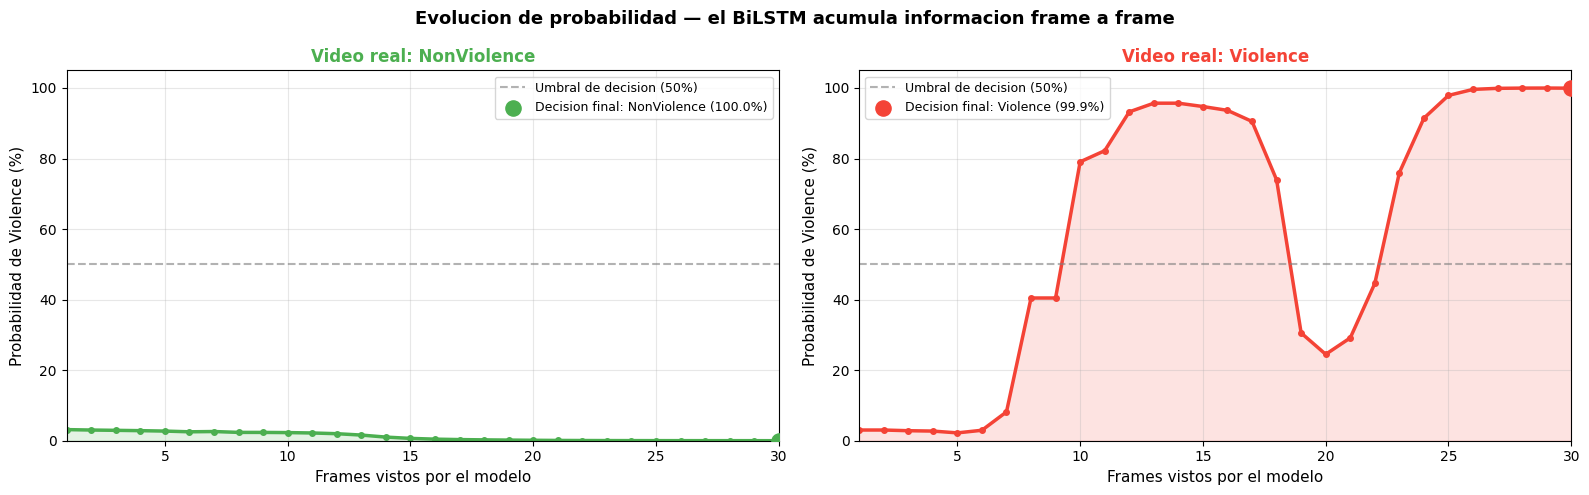

In [11]:
def probability_timeline(kp_sequence):
    """
    Calcula la probabilidad de Violence para cada prefijo de la secuencia.

    Para t = 1..30: pasa los primeros t frames al modelo (el resto en ceros)
    Retorna: lista de 30 probabilidades de Violence
    """
    timeline = []
    for t in range(1, N_FRAMES + 1):
        padded        = np.zeros_like(kp_sequence)
        padded[:t]    = kp_sequence[:t]
        x = torch.tensor(padded, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = model(x)
        timeline.append(float(out['probs'][0, 1]))   # probabilidad de Violence
    return timeline


# Calcular timelines para ambos videos
viol_kp    = extract_keypoints(viol_video)
nonviol_kp = extract_keypoints(nonviol_video)

timeline_v  = probability_timeline(viol_kp)
timeline_nv = probability_timeline(nonviol_kp)

pred_v  = predict(viol_video)
pred_nv = predict(nonviol_video)

# ── Graficar ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
frame_axis = range(1, N_FRAMES + 1)

for ax, timeline, pred, cls_name in [
    (axes[0], timeline_nv, pred_nv, 'NonViolence'),
    (axes[1], timeline_v,  pred_v,  'Violence'),
]:
    color = COLORS_CLASS[cls_name]
    ax.plot(frame_axis, [p * 100 for p in timeline],
            color=color, lw=2.5, marker='o', markersize=4)
    ax.fill_between(frame_axis, [p * 100 for p in timeline],
                    alpha=0.15, color=color)

    # Linea de decision al 50%
    ax.axhline(50, color='gray', ls='--', alpha=0.6, label='Umbral de decision (50%)')

    # Punto final (prediccion final del modelo)
    final_prob = timeline[-1] * 100
    ax.scatter([N_FRAMES], [final_prob], color=color, s=120, zorder=5,
               label=f'Decision final: {pred["pred"]} ({pred["confidence"]*100:.1f}%)')

    ax.set_xlabel('Frames vistos por el modelo', fontsize=11)
    ax.set_ylabel('Probabilidad de Violence (%)', fontsize=11)
    ax.set_title(f'Video real: {cls_name}', fontweight='bold', color=color, fontsize=12)
    ax.set_xlim(1, N_FRAMES); ax.set_ylim(0, 105)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Evolucion de probabilidad — el BiLSTM acumula informacion frame a frame',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/nb5_probability_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## Test 4 — Comparacion Visual: Violence vs NonViolence

Panel final que resume la diferencia entre ambas clases: esqueleto + probabilidades + decision.


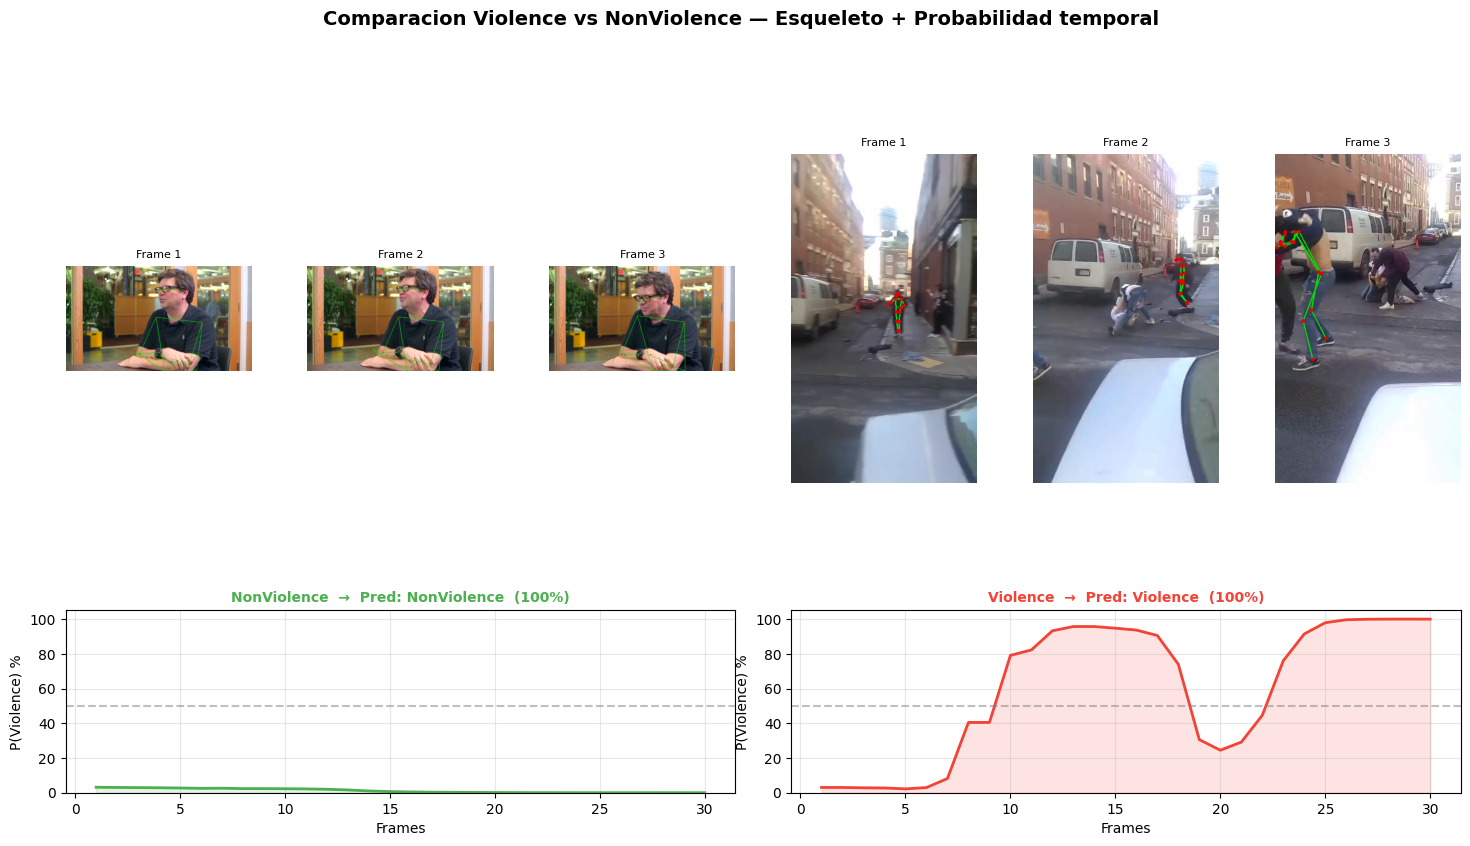

Panel comparativo guardado en output/nb5_comparison.png


In [12]:
fig = plt.figure(figsize=(18, 9))
gs  = fig.add_gridspec(3, 6, hspace=0.4, wspace=0.3)

for col_offset, (video_path, cls_name) in enumerate(
        [(nonviol_video, 'NonViolence'), (viol_video, 'Violence')]):

    frames, pred = get_frames_with_skeleton(video_path, n_display=3)
    color_hex    = COLORS_CLASS[cls_name]
    color_rgb    = tuple(int(color_hex.lstrip('#')[i:i+2], 16)/255 for i in (0,2,4))
    timeline     = timeline_nv if cls_name == 'NonViolence' else timeline_v

    # 3 frames con esqueleto (fila 0 y 1)
    for fi, frame in enumerate(frames):
        ax = fig.add_subplot(gs[:2, col_offset*3 + fi])
        ax.imshow(frame)
        ax.set_title(f'Frame {fi+1}', fontsize=8)
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_edgecolor(color_rgb); sp.set_linewidth(3)

    # Timeline (fila 2)
    ax_t = fig.add_subplot(gs[2, col_offset*3 : col_offset*3 + 3])
    ax_t.plot(range(1, N_FRAMES+1), [p*100 for p in timeline],
              color=color_hex, lw=2)
    ax_t.fill_between(range(1, N_FRAMES+1), [p*100 for p in timeline],
                      alpha=0.15, color=color_hex)
    ax_t.axhline(50, color='gray', ls='--', alpha=0.5)
    ax_t.set_ylim(0, 105); ax_t.set_xlabel('Frames'); ax_t.set_ylabel('P(Violence) %')
    ax_t.set_title(
        f'{cls_name}  →  Pred: {pred["pred"]}  ({pred["confidence"]*100:.0f}%)',
        fontweight='bold', color=color_rgb, fontsize=10)
    ax_t.grid(alpha=0.3)

fig.suptitle('Comparacion Violence vs NonViolence — Esqueleto + Probabilidad temporal',
             fontsize=14, fontweight='bold')
plt.savefig('output/nb5_comparison.png', dpi=140, bbox_inches='tight')
plt.show()
print('Panel comparativo guardado en output/nb5_comparison.png')

Procesando: prueba1unreal.mp4
Extrayendo keypoints..e.

Resultado  : Violence
Confianza  : 100.0%
NonViolence: 0.0%
Violence   : 100.0%


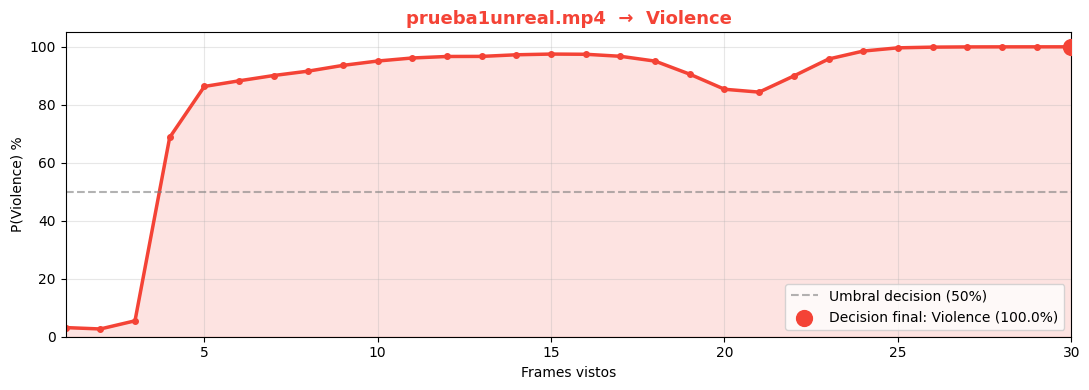

In [17]:
# ── Cambia esta ruta por tu video ─────────────────────────────────────────────
VIDEO_PATH = r'C:\Users\LENOVO\Documents\Stealth\test_videos\prueba1unreal.mp4'
# ──────────────────────────────────────────────────────────────────────────────

assert os.path.exists(VIDEO_PATH), f'No se encontro el video: {VIDEO_PATH}'

print(f'Procesando: {os.path.basename(VIDEO_PATH)}')
print('Extrayendo keypoints..e.')

result   = predict(VIDEO_PATH)
timeline = probability_timeline(result['keypoints'])

color = COLORS_CLASS[result['pred']]
print(f'\nResultado  : {result["pred"]}')
print(f'Confianza  : {result["confidence"]*100:.1f}%')
print(f'NonViolence: {result["probs"]["NonViolence"]*100:.1f}%')
print(f'Violence   : {result["probs"]["Violence"]*100:.1f}%')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1, N_FRAMES+1), [p*100 for p in timeline],
        color=color, lw=2.5, marker='o', markersize=4)
ax.fill_between(range(1, N_FRAMES+1), [p*100 for p in timeline],
                alpha=0.15, color=color)
ax.axhline(50, color='gray', ls='--', alpha=0.6, label='Umbral decision (50%)')
ax.scatter([N_FRAMES], [timeline[-1]*100], s=130, color=color, zorder=5,
           label=f'Decision final: {result["pred"]} ({result["confidence"]*100:.1f}%)')
ax.set_xlabel('Frames vistos'); ax.set_ylabel('P(Violence) %')
ax.set_title(f'{os.path.basename(VIDEO_PATH)}  →  {result["pred"]}',
             fontweight='bold', color=color, fontsize=13)
ax.set_xlim(1, N_FRAMES); ax.set_ylim(0, 105)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Extrayendo frames con esqueleto...


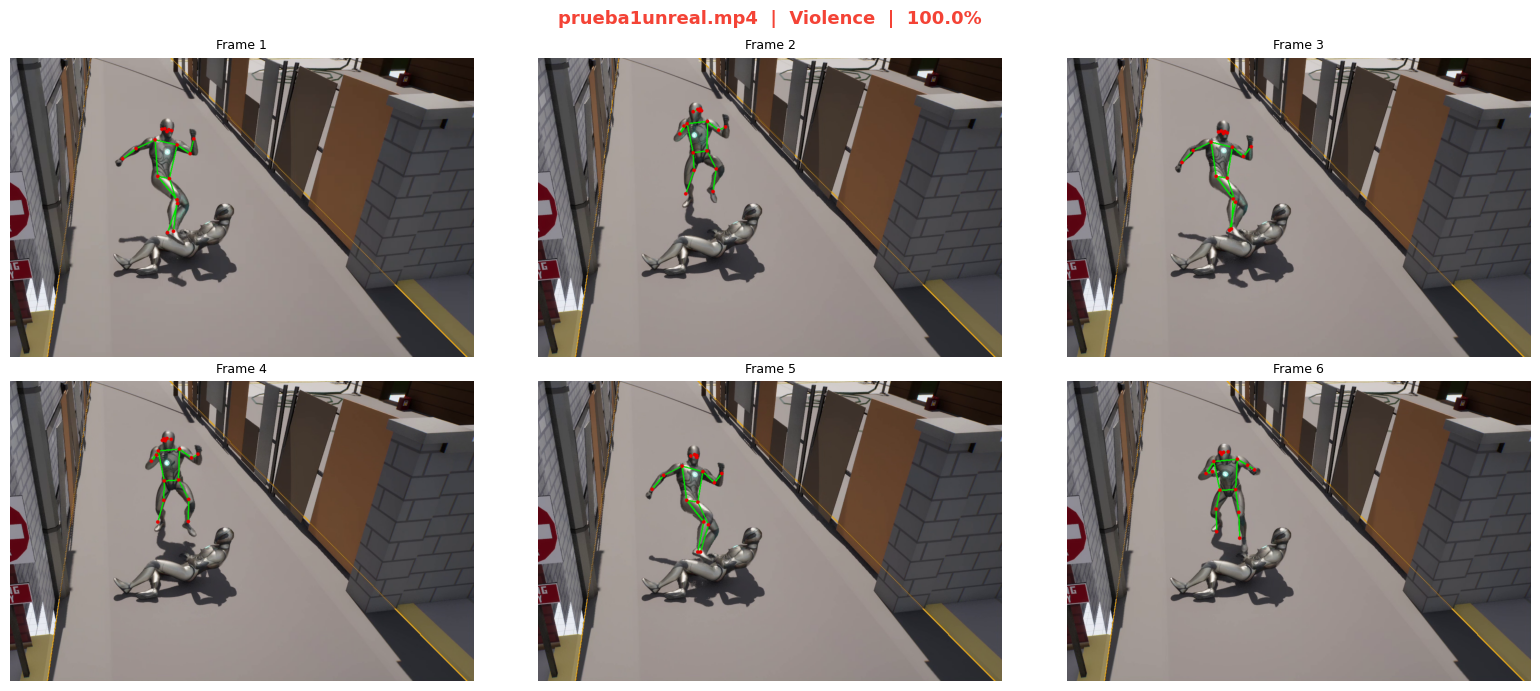

In [18]:
# ── Esqueleto sobre frames reales del video ───────────────────────────────────
print('\nExtrayendo frames con esqueleto...')
frames, _ = get_frames_with_skeleton(VIDEO_PATH, n_display=6)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()
for i, (ax, fr) in enumerate(zip(axes, frames)):
    ax.imshow(fr)
    ax.set_title(f'Frame {i+1}', fontsize=9)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3)

fig.suptitle(
    f'{os.path.basename(VIDEO_PATH)}  |  {result["pred"]}  |  {result["confidence"]*100:.1f}%',
    fontsize=13, fontweight='bold', color=color
)
plt.tight_layout()
plt.show()
